In [1]:
# ===================================================================
# Крок 1. Перевірка середовища ноутбука
# ===================================================================

import sys
from pathlib import Path

import torch

expected_python = Path(
    r"G:\GOIT\GitHub\goit-dlcv-hw12\.venv\Scripts\python.exe"
)

print("Python ноутбука:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())

assert Path(sys.executable).resolve() == expected_python.resolve(), (
    "Ноутбук використовує інше середовище. "
    "Обери ядро Python із .venv цього проєкту."
)

assert torch.cuda.is_available(), (
    "У середовищі ноутбука CUDA недоступна."
)

DEVICE = torch.device("cuda")

print("Пристрій:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Перевірку середовища ноутбука пройдено.")

Python ноутбука: g:\GOIT\GitHub\goit-dlcv-hw12\.venv\Scripts\python.exe
PyTorch: 2.6.0+cu118
CUDA доступна: True
Пристрій: cuda
GPU: NVIDIA GeForce GTX 1070 Ti
Перевірку середовища ноутбука пройдено.


In [2]:
# ===================================================================
# Крок 2. Імпорт бібліотек і початкові налаштування
# ===================================================================

import random
import time
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence,
)

import datasets
from datasets import load_dataset, DatasetDict
from tqdm.auto import tqdm
import sacrebleu


# Початкове значення для генераторів випадкових чисел.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Напрям перекладу.
SRC_LANG = "en"
TRG_LANG = "de"

DATASET_NAME = "Helsinki-NLP/europarl"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Імпорти виконано.")
print("NumPy:", np.__version__)
print("Datasets:", datasets.__version__)
print("SacreBLEU:", sacrebleu.__version__)
print("Датасет:", DATASET_NAME)
print("Напрям перекладу:", f"{SRC_LANG} → {TRG_LANG}")



Імпорти виконано.
NumPy: 2.5.3
Datasets: 5.1.0
SacreBLEU: 2.6.0
Датасет: Helsinki-NLP/europarl
Напрям перекладу: en → de


In [3]:
# ===================================================================
# Крок 3.1. Перевірка конфігурації Europarl для en–de
# ===================================================================

from datasets import get_dataset_config_names

config_names = get_dataset_config_names(DATASET_NAME)

matching_configs = [
    name
    for name in config_names
    if name in ("en-de", "de-en")
]

print("Датасет:", DATASET_NAME)
print("Кількість конфігурацій:", len(config_names))
print("Конфігурації для en–de:", matching_configs)

assert len(matching_configs) == 1, (
    "Очікували одну конфігурацію для en–de. "
    f"Знайдено: {matching_configs}"
)

DATASET_CONFIG = matching_configs[0]

print("Обрана конфігурація:", DATASET_CONFIG)
print("Напрям моделі:", f"{SRC_LANG} → {TRG_LANG}")


Датасет: Helsinki-NLP/europarl
Кількість конфігурацій: 210
Конфігурації для en–de: ['de-en']
Обрана конфігурація: de-en
Напрям моделі: en → de


In [4]:
# ===================================================================
# Крок 3.2. Завантаження Europarl для en–de
# ===================================================================

raw_dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG,
)

print("Структура датасету:")
print(raw_dataset)

assert "train" in raw_dataset, (
    "У завантаженому датасеті немає вибірки train."
)

raw_train = raw_dataset["train"]

assert len(raw_train) > 0
assert "translation" in raw_train.column_names

print("\nКількість пар:", len(raw_train))
print("Поля:", raw_train.column_names)
print("Опис типів:", raw_train.features)

print("\nПерші 5 пар:")

for index in range(min(5, len(raw_train))):
    translation = raw_train[index]["translation"]

    assert SRC_LANG in translation
    assert TRG_LANG in translation
    assert isinstance(translation[SRC_LANG], str)
    assert isinstance(translation[TRG_LANG], str)

    print(f"\nПара {index}")
    print("EN:", translation[SRC_LANG])
    print("DE:", translation[TRG_LANG])

print("\nЗавантаження та перевірку структури пройдено.")

g:\GOIT\GitHub\goit-dlcv-hw12\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eugen\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


de-en/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  180MB            

de-en/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

g:\GOIT\GitHub\goit-dlcv-hw12\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eugen\.cache\huggingface\hub\datasets--Helsinki-NLP--europarl. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating train split:   0%|          | 0/1961119 [00:00<?, ? examples/s]

Структура датасету:
DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1961119
    })
})

Кількість пар: 1961119
Поля: ['translation']
Опис типів: {'translation': Translation(languages=['de', 'en'])}

Перші 5 пар:

Пара 0
EN: Resumption of the session
DE: Wiederaufnahme der Sitzungsperiode

Пара 1
EN: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
DE: Ich erkläre die am Freitag, dem 17. Dezember unterbrochene Sitzungsperiode des Europäischen Parlaments für wiederaufgenommen, wünsche Ihnen nochmals alles Gute zum Jahreswechsel und hoffe, daß Sie schöne Ferien hatten.

Пара 2
EN: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.
DE: Wie Sie feststellen k

In [5]:
# ===================================================================
# Крок 3.3. Відбір робочої підмножини Europarl
# ===================================================================

CANDIDATE_SIZE = 100_000

assert len(raw_train) >= CANDIDATE_SIZE

# Окремий генератор: не змінює глобальний стан random.
subset_rng = random.Random(SEED)

selected_indices = subset_rng.sample(
    range(len(raw_train)),
    k=CANDIDATE_SIZE,
)

candidate_dataset = raw_train.select(selected_indices)

# Зберігаємо походження кожної пари для подальших перевірок.
candidate_dataset = candidate_dataset.add_column(
    "original_index",
    selected_indices,
)

assert len(candidate_dataset) == CANDIDATE_SIZE
assert len(set(selected_indices)) == CANDIDATE_SIZE

# Перевіряємо, що відібрані записи відповідають оригіналу.
for index in range(5):
    row = candidate_dataset[index]
    original = raw_train[row["original_index"]]

    assert row["translation"] == original["translation"]

print("Кількість пар-кандидатів:", len(candidate_dataset))
print("Поля:", candidate_dataset.column_names)

print("\nПерші 5 випадково відібраних пар:")

for index in range(5):
    row = candidate_dataset[index]

    print(
        f"\nПара {index} | "
        f"original_index={row['original_index']}"
    )
    print("EN:", row["translation"][SRC_LANG])
    print("DE:", row["translation"][TRG_LANG])

print("\nВідбір підмножини пройдено.")

Flattening the indices:   0%|          | 0/100000 [00:00<?, ? examples/s]

Кількість пар-кандидатів: 100000
Поля: ['translation', 'original_index']

Перші 5 випадково відібраних пар:

Пара 0 | original_index=1340975
EN: I believe that this can take the form of a simple letter once the NAFO agreements have been definitively ratified.
DE: Ich glaube, dass man dies in Form eines einfachen Schreibens erledigen kann, sobald die NAFO-Abkommen definitiv ratifiziert worden sind.

Пара 1 | original_index=233478
EN: It is parents themselves, indeed women themselves, who give their girls less pocket money than their boys.
DE: Und es sind die Eltern selbst, die Frauen selbst, die ihren Mädchen weniger Taschengeld geben als den Jungen.

Пара 2 | original_index=52451
EN: - (FR) The text before you, after years of negotiations seeking to define the maximum limits for weekly working hours, is symbolic in more ways than one of the ambiguities and inadequacies of European social policy.
DE: Der Text, der Ihnen nun nach jahrelangen Verhandlungen vorgelegt wurde und der auf die 

In [6]:
# ===================================================================
# Крок 3.4. Створення та перевірка токенізаторів
# ===================================================================

import spacy

nlp_en = spacy.blank("en")
nlp_de = spacy.blank("de")


def tokenize_en(text):
    return [
        token.text
        for token in nlp_en.make_doc(text.strip())
        if not token.is_space
    ]


def tokenize_de(text):
    return [
        token.text
        for token in nlp_de.make_doc(text.strip())
        if not token.is_space
    ]


assert nlp_en.lang == SRC_LANG
assert nlp_de.lang == TRG_LANG

print("Версія spaCy:", spacy.__version__)
print("Мова вхідного токенізатора:", nlp_en.lang)
print("Мова цільового токенізатора:", nlp_de.lang)

for index in range(3):
    translation = candidate_dataset[index]["translation"]

    src_tokens = tokenize_en(translation[SRC_LANG])
    trg_tokens = tokenize_de(translation[TRG_LANG])

    assert len(src_tokens) > 0
    assert len(trg_tokens) > 0
    assert all(token.strip() for token in src_tokens)
    assert all(token.strip() for token in trg_tokens)

    print(f"\nПара {index}")
    print(f"EN ({len(src_tokens)} токенів):", src_tokens)
    print(f"DE ({len(trg_tokens)} токенів):", trg_tokens)

print("\nПеревірку токенізаторів пройдено.")

Версія spaCy: 3.8.16
Мова вхідного токенізатора: en
Мова цільового токенізатора: de

Пара 0
EN (21 токенів): ['I', 'believe', 'that', 'this', 'can', 'take', 'the', 'form', 'of', 'a', 'simple', 'letter', 'once', 'the', 'NAFO', 'agreements', 'have', 'been', 'definitively', 'ratified', '.']
DE (22 токенів): ['Ich', 'glaube', ',', 'dass', 'man', 'dies', 'in', 'Form', 'eines', 'einfachen', 'Schreibens', 'erledigen', 'kann', ',', 'sobald', 'die', 'NAFO-Abkommen', 'definitiv', 'ratifiziert', 'worden', 'sind', '.']

Пара 1
EN (20 токенів): ['It', 'is', 'parents', 'themselves', ',', 'indeed', 'women', 'themselves', ',', 'who', 'give', 'their', 'girls', 'less', 'pocket', 'money', 'than', 'their', 'boys', '.']
DE (21 токенів): ['Und', 'es', 'sind', 'die', 'Eltern', 'selbst', ',', 'die', 'Frauen', 'selbst', ',', 'die', 'ihren', 'Mädchen', 'weniger', 'Taschengeld', 'geben', 'als', 'den', 'Jungen', '.']

Пара 2
EN (41 токенів): ['-', '(', 'FR', ')', 'The', 'text', 'before', 'you', ',', 'after', 'yea

In [8]:
# ===================================================================
# Крок 3.5. Токенізація підмножини та перевірка довжин
# ===================================================================

def tokenize_batch(batch):
    translations = batch["translation"]

    src_texts = [
        item[SRC_LANG].strip()
        for item in translations
    ]
    trg_texts = [
        item[TRG_LANG].strip()
        for item in translations
    ]

    src_tokens = [
        [token.text for token in doc if not token.is_space]
        for doc in nlp_en.tokenizer.pipe(src_texts)
    ]

    trg_tokens = [
        [token.text for token in doc if not token.is_space]
        for doc in nlp_de.tokenizer.pipe(trg_texts)
    ]

    return {
        "src_tokens": src_tokens,
        "trg_tokens": trg_tokens,
        "src_length": [len(tokens) for tokens in src_tokens],
        "trg_length": [len(tokens) for tokens in trg_tokens],
    }


tokenized_candidates = candidate_dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=256,
    desc="Токенізація en–de",
)

assert len(tokenized_candidates) == len(candidate_dataset)

assert (
    tokenized_candidates["original_index"]
    == candidate_dataset["original_index"]
)

for index in range(5):
    row = tokenized_candidates[index]

    assert row["translation"] == candidate_dataset[index]["translation"]
    assert row["src_tokens"] == tokenize_en(
        row["translation"][SRC_LANG]
    )
    assert row["trg_tokens"] == tokenize_de(
        row["translation"][TRG_LANG]
    )

src_lengths = np.asarray(
    tokenized_candidates["src_length"],
    dtype=np.int64,
)
trg_lengths = np.asarray(
    tokenized_candidates["trg_length"],
    dtype=np.int64,
)

print("Токенізовано пар:", len(tokenized_candidates))
print("Поля:", tokenized_candidates.column_names)

for language, lengths in (
    ("EN", src_lengths),
    ("DE", trg_lengths),
):
    print(f"\n{language}:")
    print("Порожніх послідовностей:", int((lengths == 0).sum()))
    print("Мінімальна довжина:", int(lengths.min()))
    print("Середня довжина:", round(float(lengths.mean()), 2))
    print("Максимальна довжина:", int(lengths.max()))

   
print("\nКількість пар у межах довжини для обох мов:")

for limit in (30, 40, 50, 60):
    fits = (
        (src_lengths > 0)
        & (trg_lengths > 0)
        & (src_lengths <= limit)
        & (trg_lengths <= limit)
    )

    count = int(fits.sum())

    print(
        f"До {limit} токенів: "
        f"{count} пар ({count / len(tokenized_candidates):.2%})"
    )

print("\nТокенізацію та перевірку довжин завершено.")

Токенізація en–de:   0%|          | 0/100000 [00:00<?, ? examples/s]

Токенізовано пар: 100000
Поля: ['translation', 'original_index', 'src_tokens', 'trg_tokens', 'src_length', 'trg_length']

EN:
Порожніх послідовностей: 0
Мінімальна довжина: 1
Середня довжина: 27.9
Максимальна довжина: 621

DE:
Порожніх послідовностей: 0
Мінімальна довжина: 1
Середня довжина: 26.35
Максимальна довжина: 607

Кількість пар у межах довжини для обох мов:
До 30 токенів: 61372 пар (61.37%)
До 40 токенів: 79689 пар (79.69%)
До 50 токенів: 89909 пар (89.91%)
До 60 токенів: 95132 пар (95.13%)

Токенізацію та перевірку довжин завершено.


In [9]:
# ===================================================================
# Крок 3.6. Фільтрація пар за довжиною
# ===================================================================

MAX_TEXT_TOKENS = 40


def passes_length_filter(row):
    return (
        1 <= row["src_length"] <= MAX_TEXT_TOKENS
        and 1 <= row["trg_length"] <= MAX_TEXT_TOKENS
    )


length_filtered_dataset = tokenized_candidates.filter(
    passes_length_filter,
    desc="Фільтрація довжини en–de",
)

expected_count = int(
    (
        (src_lengths >= 1)
        & (trg_lengths >= 1)
        & (src_lengths <= MAX_TEXT_TOKENS)
        & (trg_lengths <= MAX_TEXT_TOKENS)
    ).sum()
)

assert len(length_filtered_dataset) == expected_count
assert len(length_filtered_dataset) > 0

for row in length_filtered_dataset:
    assert row["src_length"] == len(row["src_tokens"])
    assert row["trg_length"] == len(row["trg_tokens"])
    assert 1 <= row["src_length"] <= MAX_TEXT_TOKENS
    assert 1 <= row["trg_length"] <= MAX_TEXT_TOKENS

removed_count = (
    len(tokenized_candidates) - len(length_filtered_dataset)
)

print("Максимальна довжина без <bos>/<eos>:", MAX_TEXT_TOKENS)
print("До фільтрації:", len(tokenized_candidates))
print("Після фільтрації:", len(length_filtered_dataset))
print("Видалено пар:", removed_count)
print(
    "Збережено:",
    f"{len(length_filtered_dataset) / len(tokenized_candidates):.2%}",
)
print("Речення не обрізалися.")
print("Перевірку фільтрації довжини пройдено.")

Фільтрація довжини en–de:   0%|          | 0/100000 [00:00<?, ? examples/s]

Максимальна довжина без <bos>/<eos>: 40
До фільтрації: 100000
Після фільтрації: 79689
Видалено пар: 20311
Збережено: 79.69%
Речення не обрізалися.
Перевірку фільтрації довжини пройдено.


In [10]:
# ===================================================================
# Крок 3.7. Видалення дублікатів пар
# ===================================================================

def text_comparison_key(text):
    return " ".join(text.split())


seen_pairs = set()
keep_indices = []
duplicate_count = 0

for index, row in enumerate(
    tqdm(length_filtered_dataset, desc="Перевірка дублікатів")
):
    translation = row["translation"]

    pair_key = (
        text_comparison_key(translation[SRC_LANG]),
        text_comparison_key(translation[TRG_LANG]),
    )

    if pair_key in seen_pairs:
        duplicate_count += 1
        continue

    seen_pairs.add(pair_key)
    keep_indices.append(index)


deduplicated_dataset = length_filtered_dataset.select(
    keep_indices
)

assert (
    len(deduplicated_dataset) + duplicate_count
    == len(length_filtered_dataset)
)

assert len(deduplicated_dataset) == len(seen_pairs)

# Незалежна перевірка результату.
verified_pairs = set()

for row in deduplicated_dataset:
    translation = row["translation"]

    pair_key = (
        text_comparison_key(translation[SRC_LANG]),
        text_comparison_key(translation[TRG_LANG]),
    )

    assert pair_key not in verified_pairs
    verified_pairs.add(pair_key)

print("До видалення дублікатів:", len(length_filtered_dataset))
print("Повторів пар видалено:", duplicate_count)
print("Унікальних пар залишилося:", len(deduplicated_dataset))
print("Тексти й токени не змінювалися.")
print("Перевірку дублікатів пройдено.")

Перевірка дублікатів:   0%|          | 0/79689 [00:00<?, ?it/s]

До видалення дублікатів: 79689
Повторів пар видалено: 1451
Унікальних пар залишилося: 78238
Тексти й токени не змінювалися.
Перевірку дублікатів пройдено.


In [11]:
# ===================================================================
# Крок 3.8. Розбиття та перевірка перетинів
# ===================================================================

VALIDATION_SIZE = 2_000
TEST_SIZE = 2_000

assert len(deduplicated_dataset) > VALIDATION_SIZE + TEST_SIZE

train_holdout = deduplicated_dataset.train_test_split(
    test_size=VALIDATION_SIZE + TEST_SIZE,
    shuffle=True,
    seed=SEED,
)

validation_test = train_holdout["test"].train_test_split(
    test_size=TEST_SIZE,
    shuffle=True,
    seed=SEED,
)

split_dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": validation_test["train"],
    "test": validation_test["test"],
})

assert sum(len(split) for split in split_dataset.values()) == len(
    deduplicated_dataset
)

index_sets = {}
pair_sets = {}
src_sets = {}
trg_sets = {}

for split_name, split in split_dataset.items():
    index_sets[split_name] = set(split["original_index"])
    pair_sets[split_name] = set()
    src_sets[split_name] = set()
    trg_sets[split_name] = set()

    for row in split:
        translation = row["translation"]

        src_key = text_comparison_key(translation[SRC_LANG])
        trg_key = text_comparison_key(translation[TRG_LANG])

        pair_sets[split_name].add((src_key, trg_key))
        src_sets[split_name].add(src_key)
        trg_sets[split_name].add(trg_key)

    assert len(index_sets[split_name]) == len(split)
    assert len(pair_sets[split_name]) == len(split)

    print(f"{split_name}: {len(split)} пар")

print("\nПеретини між вибірками:")

for first, second in (
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
):
    shared_indices = index_sets[first] & index_sets[second]
    shared_pairs = pair_sets[first] & pair_sets[second]

    assert not shared_indices
    assert not shared_pairs

    print(f"\n{first} / {second}")
    print("Спільних початкових індексів:", len(shared_indices))
    print("Спільних повних пар:", len(shared_pairs))
    print(
        "Спільних EN-речень:",
        len(src_sets[first] & src_sets[second]),
    )
    print(
        "Спільних DE-речень:",
        len(trg_sets[first] & trg_sets[second]),
    )

print("\nРозбиття створено. Перетини повних пар відсутні.")

train: 74238 пар
validation: 2000 пар
test: 2000 пар

Перетини між вибірками:

train / validation
Спільних початкових індексів: 0
Спільних повних пар: 0
Спільних EN-речень: 12
Спільних DE-речень: 9

train / test
Спільних початкових індексів: 0
Спільних повних пар: 0
Спільних EN-речень: 11
Спільних DE-речень: 7

validation / test
Спільних початкових індексів: 0
Спільних повних пар: 0
Спільних EN-речень: 1
Спільних DE-речень: 0

Розбиття створено. Перетини повних пар відсутні.


In [12]:
# ===================================================================
# Крок 3.9. Усунення міжвибіркових перетинів речень
# ===================================================================

def get_sentence_sets(dataset):
    src_keys = set()
    trg_keys = set()

    for row in dataset:
        translation = row["translation"]
        src_keys.add(text_comparison_key(translation[SRC_LANG]))
        trg_keys.add(text_comparison_key(translation[TRG_LANG]))

    return src_keys, trg_keys


def has_no_blocked_sentence(row, blocked_src, blocked_trg):
    translation = row["translation"]

    return (
        text_comparison_key(translation[SRC_LANG]) not in blocked_src
        and text_comparison_key(translation[TRG_LANG]) not in blocked_trg
    )


train_src_keys, train_trg_keys = get_sentence_sets(
    split_dataset["train"]
)

validation_clean = split_dataset["validation"].filter(
    has_no_blocked_sentence,
    fn_kwargs={
        "blocked_src": train_src_keys,
        "blocked_trg": train_trg_keys,
    },
    desc="Усунення перетинів validation",
)

validation_src_keys, validation_trg_keys = get_sentence_sets(
    validation_clean
)

test_clean = split_dataset["test"].filter(
    has_no_blocked_sentence,
    fn_kwargs={
        "blocked_src": train_src_keys | validation_src_keys,
        "blocked_trg": train_trg_keys | validation_trg_keys,
    },
    desc="Усунення перетинів test",
)

clean_dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": validation_clean,
    "test": test_clean,
})

sentence_sets = {}

for split_name, split in clean_dataset.items():
    assert len(split) > 0
    sentence_sets[split_name] = get_sentence_sets(split)

    removed = len(split_dataset[split_name]) - len(split)

    print(
        f"{split_name}: {len(split)} пар | "
        f"видалено через перетини: {removed}"
    )

print("\nПовторна перевірка перетинів:")

for first, second in (
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
):
    first_src, first_trg = sentence_sets[first]
    second_src, second_trg = sentence_sets[second]

    shared_src = first_src & second_src
    shared_trg = first_trg & second_trg

    assert not shared_src
    assert not shared_trg

    print(
        f"{first} / {second}: "
        f"EN={len(shared_src)}, DE={len(shared_trg)}"
    )

print("\nПеревірку розділення даних пройдено.")

Усунення перетинів validation:   0%|          | 0/2000 [00:00<?, ? examples/s]

Усунення перетинів test:   0%|          | 0/2000 [00:00<?, ? examples/s]

train: 74238 пар | видалено через перетини: 0
validation: 1979 пар | видалено через перетини: 21
test: 1983 пар | видалено через перетини: 17

Повторна перевірка перетинів:
train / validation: EN=0, DE=0
train / test: EN=0, DE=0
validation / test: EN=0, DE=0

Перевірку розділення даних пройдено.


In [15]:
# ===================================================================
# Крок 3.10. Створення словників із навчальної вибірки
# ===================================================================

SPECIAL_TOKENS = ["<pad>", "<unk>", "<bos>", "<eos>"]

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

MIN_FREQ = 2


def build_vocabulary(token_sequences, min_freq):
    counter = Counter()

    for tokens in token_sequences:
        counter.update(tokens)

    vocabulary_tokens = [
        token
        for token, count in sorted(
            counter.items(),
            key=lambda item: (-item[1], item[0]),
        )
        if count >= min_freq and token not in SPECIAL_TOKENS
    ]

    itos = SPECIAL_TOKENS + vocabulary_tokens
    stoi = {
        token: index
        for index, token in enumerate(itos)
    }

    return stoi, itos, counter


src_stoi, src_itos, src_counter = build_vocabulary(
    clean_dataset["train"]["src_tokens"],
    min_freq=MIN_FREQ,
)

trg_stoi, trg_itos, trg_counter = build_vocabulary(
    clean_dataset["train"]["trg_tokens"],
    min_freq=MIN_FREQ,
)

SRC_VOCAB_SIZE = len(src_itos)
TRG_VOCAB_SIZE = len(trg_itos)

for stoi, itos in (
    (src_stoi, src_itos),
    (trg_stoi, trg_itos),
):
    assert len(stoi) == len(itos)
    assert itos[:4] == SPECIAL_TOKENS

    for index, token in enumerate(itos):
        assert stoi[token] == index

    assert stoi["<pad>"] == PAD_IDX
    assert stoi["<unk>"] == UNK_IDX
    assert stoi["<bos>"] == BOS_IDX
    assert stoi["<eos>"] == EOS_IDX

assert sum(src_counter.values()) == sum(
    clean_dataset["train"]["src_length"]
)
assert sum(trg_counter.values()) == sum(
    clean_dataset["train"]["trg_length"]
)

print("MIN_FREQ:", MIN_FREQ)
print("Розмір англійського словника:", SRC_VOCAB_SIZE)
print("Розмір німецького словника:", TRG_VOCAB_SIZE)

print("\nПерші 15 EN-токенів:")
print(src_itos[:15])

print("\nПерші 15 DE-токенів:")
print(trg_itos[:15])

print("\nІндекси спеціальних токенів:")
for token in SPECIAL_TOKENS:
    print(
        f"{token}: EN={src_stoi[token]}, "
        f"DE={trg_stoi[token]}"
    )

print("\nПеревірку створення словників пройдено.")

MIN_FREQ: 2
Розмір англійського словника: 17658
Розмір німецького словника: 29668

Перші 15 EN-токенів:
['<pad>', '<unk>', '<bos>', '<eos>', 'the', '.', ',', 'of', 'to', 'and', 'in', 'is', 'that', 'a', 'I']

Перші 15 DE-токенів:
['<pad>', '<unk>', '<bos>', '<eos>', ',', '.', 'die', 'der', 'und', 'in', 'zu', 'den', 'ist', 'für', 'von']

Індекси спеціальних токенів:
<pad>: EN=0, DE=0
<unk>: EN=1, DE=1
<bos>: EN=2, DE=2
<eos>: EN=3, DE=3

Перевірку створення словників пройдено.


In [16]:
# ===================================================================
# Крок 3.11. Перевірка покриття словників
# ===================================================================

def vocabulary_coverage(token_sequences, vocabulary):
    total_tokens = 0
    unknown_tokens = 0
    sentences_with_unknown = 0

    for tokens in token_sequences:
        unknown_count = sum(
            token not in vocabulary
            for token in tokens
        )

        total_tokens += len(tokens)
        unknown_tokens += unknown_count
        sentences_with_unknown += int(unknown_count > 0)

    return {
        "total_tokens": total_tokens,
        "unknown_tokens": unknown_tokens,
        "unknown_rate": (
            unknown_tokens / total_tokens
            if total_tokens else 0.0
        ),
        "sentences_with_unknown": sentences_with_unknown,
    }


coverage_stats = {}

for split_name, split in clean_dataset.items():
    coverage_stats[split_name] = {}

    print(f"\nВибірка: {split_name}")

    for language, column, vocabulary in (
        ("EN", "src_tokens", src_stoi),
        ("DE", "trg_tokens", trg_stoi),
    ):
        stats = vocabulary_coverage(
            split[column],
            vocabulary,
        )

        coverage_stats[split_name][language] = stats

        assert stats["total_tokens"] > 0
        assert 0 <= stats["unknown_tokens"] <= stats["total_tokens"]
        assert 0 <= stats["sentences_with_unknown"] <= len(split)

        print(
            f"{language}: "
            f"невідомих токенів "
            f"{stats['unknown_tokens']}/{stats['total_tokens']} "
            f"({stats['unknown_rate']:.2%}); "
            f"речень із невідомими токенами "
            f"{stats['sentences_with_unknown']}/{len(split)}"
        )

print("\nПеревірку покриття словників завершено.")


Вибірка: train
EN: невідомих токенів 11011/1623291 (0.68%); речень із невідомими токенами 8965/74238
DE: невідомих токенів 33937/1535428 (2.21%); речень із невідомими токенами 24467/74238

Вибірка: validation
EN: невідомих токенів 490/43645 (1.12%); речень із невідомими токенами 379/1979
DE: невідомих токенів 1327/41379 (3.21%); речень із невідомими токенами 878/1979

Вибірка: test
EN: невідомих токенів 456/43016 (1.06%); речень із невідомими токенами 350/1983
DE: невідомих токенів 1353/40804 (3.32%); речень із невідомими токенами 859/1983

Перевірку покриття словників завершено.


In [17]:
# ===================================================================
# Крок 3.12. Числове кодування
# ===================================================================

def numericalize_batch(batch, src_vocab, trg_vocab):
    src_token_lists = batch["src_tokens"]
    trg_token_lists = batch["trg_tokens"]

    src_ids = []
    trg_ids = []

    for src_tokens, trg_tokens in zip(src_token_lists, trg_token_lists):
        src_sequence = [
            BOS_IDX,
            *[
                src_vocab.get(token, UNK_IDX)
                for token in src_tokens
            ],
            EOS_IDX,
        ]

        trg_sequence = [
            BOS_IDX,
            *[
                trg_vocab.get(token, UNK_IDX)
                for token in trg_tokens
            ],
            EOS_IDX,
        ]

        src_ids.append(src_sequence)
        trg_ids.append(trg_sequence)

    return {
        "src_ids": src_ids,
        "trg_ids": trg_ids,
        "src_ids_length": [len(seq) for seq in src_ids],
        "trg_ids_length": [len(seq) for seq in trg_ids],
    }


numericalized_dataset = clean_dataset.map(
    numericalize_batch,
    fn_kwargs={
        "src_vocab": src_stoi,
        "trg_vocab": trg_stoi,
    },
    batched=True,
    batch_size=256,
    desc="Числове кодування",
)

assert len(numericalized_dataset["train"]) == len(clean_dataset["train"])
assert len(numericalized_dataset["validation"]) == len(
    clean_dataset["validation"]
)
assert len(numericalized_dataset["test"]) == len(clean_dataset["test"])

print("Числове кодування виконано.")
print("Поля:", numericalized_dataset["train"].column_names)

for split_name, split in numericalized_dataset.items():
    src_lengths = np.asarray(split["src_ids_length"])
    trg_lengths = np.asarray(split["trg_ids_length"])

    print(f"\n{split_name}: {len(split)} пар")
    print(
        f"EN довжина з <bos>/<eos>: "
        f"мін={int(src_lengths.min())}, "
        f"макс={int(src_lengths.max())}, "
        f"середнє={float(src_lengths.mean()):.2f}"
    )
    print(
        f"DE довжина з <bos>/<eos>: "
        f"мін={int(trg_lengths.min())}, "
        f"макс={int(trg_lengths.max())}, "
        f"середнє={float(trg_lengths.mean()):.2f}"
    )

    # Перевірка відповідності токенів/індексів для перших 3 пар.
    for index in range(min(3, len(split))):
        row = split[index]
        clean_row = clean_dataset[split_name][index]

        assert row["src_ids"][0] == BOS_IDX
        assert row["src_ids"][-1] == EOS_IDX
        assert row["trg_ids"][0] == BOS_IDX
        assert row["trg_ids"][-1] == EOS_IDX

        assert len(row["src_ids"]) == len(
            clean_row["src_tokens"]
        ) + 2
        assert len(row["trg_ids"]) == len(
            clean_row["trg_tokens"]
        ) + 2

        for token, idx in zip(
            clean_row["src_tokens"], row["src_ids"][1:-1]
        ):
            expected = src_stoi.get(token, UNK_IDX)
            assert idx == expected, (
                f"Неспівпадіння EN токена: {token}"
            )

        for token, idx in zip(
            clean_row["trg_tokens"], row["trg_ids"][1:-1]
        ):
            expected = trg_stoi.get(token, UNK_IDX)
            assert idx == expected, (
                f"Неспівпадіння DE токена: {token}"
            )

print("\nПеревірку числового кодування пройдено.")

Числове кодування:   0%|          | 0/74238 [00:00<?, ? examples/s]

Числове кодування:   0%|          | 0/1979 [00:00<?, ? examples/s]

Числове кодування:   0%|          | 0/1983 [00:00<?, ? examples/s]

Числове кодування виконано.
Поля: ['translation', 'original_index', 'src_tokens', 'trg_tokens', 'src_length', 'trg_length', 'src_ids', 'trg_ids', 'src_ids_length', 'trg_ids_length']

train: 74238 пар
EN довжина з <bos>/<eos>: мін=3, макс=42, середнє=23.87
DE довжина з <bos>/<eos>: мін=3, макс=42, середнє=22.68

validation: 1979 пар
EN довжина з <bos>/<eos>: мін=3, макс=42, середнє=24.05
DE довжина з <bos>/<eos>: мін=3, макс=42, середнє=22.91

test: 1983 пар
EN довжина з <bos>/<eos>: мін=4, макс=42, середнє=23.69
DE довжина з <bos>/<eos>: мін=3, макс=42, середнє=22.58

Перевірку числового кодування пройдено.


In [32]:
# ===================================================================
# Додаток до кроку 3.13: Індекс → токен
# ===================================================================

SRC_ITOS = {idx: tok for tok, idx in src_stoi.items()}
TRG_ITOS = {idx: tok for tok, idx in trg_stoi.items()}

# Перевірка
print("SRC_ITOS[0]:", SRC_ITOS[0])   # <pad>
print("SRC_ITOS[1]:", SRC_ITOS[1])   # <unk>
print("SRC_ITOS[2]:", SRC_ITOS[2])   # <bos>
print("SRC_ITOS[3]:", SRC_ITOS[3])   # <eos>
print("TRG_VOCAB_SIZE:", len(TRG_ITOS))

SRC_ITOS[0]: <pad>
SRC_ITOS[1]: <unk>
SRC_ITOS[2]: <bos>
SRC_ITOS[3]: <eos>
TRG_VOCAB_SIZE: 29668


#### Підсумки підготовки даних

Виконано:
| Етап               | Результат                                                                                                                     |
| ------------------ | ----------------------------------------------------------------------------------------------------------------------------- |
| Датасет            | Helsinki-NLP/europarl, конфігурація de-en (1 961 119 пар).                                                                    |
| Напрям             | Англійська → Німецька (en → de). Поле en — вхід, de — ціль.                                                                   |
| Робоча підмножина  | 100 000 випадкових пар (seed 42).                                                                                             |
| Токенізація        | spacy.blank("en") / spacy.blank("de") — регістр і пунктуація збережено.                                                       |
| Фільтрація довжини | MAX_TEXT_TOKENS = 40 → залишилось 79 689 пар (79.69%).                                                                        |
| Дублікати пар      | Видалено 1 451 повних повторів → 78 238 унікальних пар.                                                                       |
| Розбиття           | train 74 238 / validation 2 000 / test 2 000 (stratified by train_test_split, seed 42).                                       |
| Перетини речень    | Усунуто перетини EN/DE між вибірками: validation 1 979 / test 1 983 (видалено 21 + 17 пар).                                   |
| Словники           | Побудовано лише з train (MIN_FREQ = 2): EN 17 658 / DE 29 668 токенів. Спеціальні токени: <pad>=0, èrent=1, <bos>=2, <eos>=3. |
| Покриття словників | Train: EN 0.68% / DE 2.21% èrent; Validation: EN 1.12% / DE 3.21%; Test: EN 1.06% / DE 3.32%.                                 |
| Числове кодування  | <bos> + токени + <eos> → довжина 3–42.                                                                                        |








In [33]:
# ===================================================================
# Крок 4.1. PyTorch Dataset та DataLoader
# ===================================================================

from torch.utils.data import Dataset as TorchDataset
from torch.nn.utils.rnn import pad_sequence


class TranslationDataset(TorchDataset):
    def __init__(self, hf_dataset):
        self.src_ids = hf_dataset["src_ids"]
        self.trg_ids = hf_dataset["trg_ids"]
        self.src_lengths = hf_dataset["src_ids_length"]
        self.trg_lengths = hf_dataset["trg_ids_length"]

    def __len__(self):
        return len(self.src_ids)

    def __getitem__(self, index):
        return {
            "src": torch.tensor(self.src_ids[index], dtype=torch.long),
            "trg": torch.tensor(self.trg_ids[index], dtype=torch.long),
            "src_length": self.src_lengths[index],
            "trg_length": self.trg_lengths[index],
        }


def collate_fn(batch):
    src_batch = pad_sequence(
        [item["src"] for item in batch],
        batch_first=True,
        padding_value=PAD_IDX,
    )

    trg_batch = pad_sequence(
        [item["trg"] for item in batch],
        batch_first=True,
        padding_value=PAD_IDX,
    )

    src_lengths = torch.tensor(
        [item["src_length"] for item in batch],
        dtype=torch.long,
    )

    trg_lengths = torch.tensor(
        [item["trg_length"] for item in batch],
        dtype=torch.long,
    )

    src_mask = src_batch.ne(PAD_IDX)

    return {
        "src": src_batch,
        "trg": trg_batch,
        "src_lengths": src_lengths,
        "trg_lengths": trg_lengths,
        "src_mask": src_mask,
    }


BATCH_SIZE = 32
SEED = 42

train_dataset = TranslationDataset(numericalized_dataset["train"])
validation_dataset = TranslationDataset(numericalized_dataset["validation"])
test_dataset = TranslationDataset(numericalized_dataset["test"])

train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    generator=train_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)


# Перевірка одного батчу.
batch = next(iter(train_loader))

print("Ключі батчу:", list(batch.keys()))
print("Форми:")
for key, value in batch.items():
    print(f"  {key}: {tuple(value.shape)} {value.dtype}")

assert batch["src"].dtype == torch.long
assert batch["trg"].dtype == torch.long
assert batch["src_mask"].dtype == torch.bool
assert batch["src"].size(0) == BATCH_SIZE
assert batch["src"].size(1) == batch["src_mask"].size(1)

for prefix in ("src", "trg"):
    sequences = batch[prefix]
    lengths = batch[f"{prefix}_lengths"]

    assert torch.equal(
        sequences.ne(PAD_IDX).sum(dim=1),
        lengths,
    )

    for seq, length in zip(sequences, lengths.tolist()):
        assert seq[0].item() == BOS_IDX
        assert seq[length - 1].item() == EOS_IDX
        assert torch.all(seq[length:] == PAD_IDX)

print("\nПеревірку DataLoader пройдено.")

Ключі батчу: ['src', 'trg', 'src_lengths', 'trg_lengths', 'src_mask']
Форми:
  src: (32, 40) torch.int64
  trg: (32, 39) torch.int64
  src_lengths: (32,) torch.int64
  trg_lengths: (32,) torch.int64
  src_mask: (32, 40) torch.bool

Перевірку DataLoader пройдено.


In [34]:
# ===================================================================
# Крок 4.2. Енкодер
# ===================================================================

class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden_dim,
        dec_hidden_dim,
        dropout,
        pad_idx,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx,
        )

        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=enc_hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.hidden_bridge = nn.Linear(
            enc_hidden_dim * 2,
            dec_hidden_dim,
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))

        packed = pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        packed_outputs, hidden = self.gru(packed)

        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=src.size(1),
        )

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        combined_hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1,
        )

        decoder_hidden = torch.tanh(
            self.hidden_bridge(combined_hidden)
        )

        return outputs, decoder_hidden

In [35]:
# ===================================================================
# Крок 4.3. Механізм уваги Bahdanau
# ===================================================================

class BahdanauAttention(nn.Module):
    def __init__(
        self,
        enc_hidden_dim,
        dec_hidden_dim,
        attention_dim,
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            enc_hidden_dim * 2,
            attention_dim,
            bias=False,
        )

        self.decoder_projection = nn.Linear(
            dec_hidden_dim,
            attention_dim,
            bias=False,
        )

        self.score_projection = nn.Linear(
            attention_dim,
            1,
            bias=False,
        )

    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        encoder_features = self.encoder_projection(encoder_outputs)
        decoder_features = self.decoder_projection(
            decoder_hidden
        ).unsqueeze(1)

        energy = torch.tanh(
            encoder_features + decoder_features
        )

        scores = self.score_projection(energy).squeeze(-1)

        scores = scores.masked_fill(~src_mask, float("-inf"))

        weights = torch.softmax(scores, dim=1)

        context = torch.bmm(
            weights.unsqueeze(1),
            encoder_outputs,
        ).squeeze(1)

        return context, weights

In [36]:
# ===================================================================
# Крок 4.4. Декодер
# ===================================================================

class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden_dim,
        dec_hidden_dim,
        dropout,
        pad_idx,
        attention,
    ):
        super().__init__()

        self.attention = attention

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx,
        )

        self.dropout = nn.Dropout(dropout)

        context_dim = enc_hidden_dim * 2

        self.gru = nn.GRU(
            input_size=embed_dim + context_dim,
            hidden_size=dec_hidden_dim,
            num_layers=1,
            batch_first=True,
        )

        self.output_projection = nn.Linear(
            dec_hidden_dim + context_dim + embed_dim,
            vocab_size,
        )

    def forward(
        self,
        input_token,
        decoder_hidden,
        encoder_outputs,
        src_mask,
    ):
        embedded = self.dropout(self.embedding(input_token))

        context, attention_weights = self.attention(
            decoder_hidden,
            encoder_outputs,
            src_mask,
        )

        gru_input = torch.cat(
            (embedded, context),
            dim=1,
        ).unsqueeze(1)

        gru_output, next_hidden = self.gru(
            gru_input,
            decoder_hidden.unsqueeze(0),
        )

        gru_output = gru_output.squeeze(1)
        next_hidden = next_hidden.squeeze(0)

        output_features = torch.cat(
            (gru_output, context, embedded),
            dim=1,
        )

        logits = self.output_projection(output_features)

        return logits, next_hidden, attention_weights

In [37]:
# ===================================================================
# Крок 4.5. Seq2Seq
# ===================================================================

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        src_lengths,
        trg,
        src_mask,
        teacher_forcing_ratio=0.5,
    ):
        if not 0.0 <= teacher_forcing_ratio <= 1.0:
            raise ValueError(
                "teacher_forcing_ratio має бути в межах [0, 1]."
            )

        if trg.size(1) < 2:
            raise ValueError(
                "Цільова послідовність має містити <bos> і наступний токен."
            )

        encoder_outputs, hidden = self.encoder(src, src_lengths)

        input_token = trg[:, 0]

        all_logits = []
        all_attention_weights = []

        for t in range(1, trg.size(1)):
            logits, hidden, attention_weights = self.decoder(
                input_token,
                hidden,
                encoder_outputs,
                src_mask,
            )

            all_logits.append(logits)
            all_attention_weights.append(attention_weights)

            if teacher_forcing_ratio == 1.0:
                use_teacher_forcing = True
            elif teacher_forcing_ratio == 0.0:
                use_teacher_forcing = False
            else:
                use_teacher_forcing = (
                    random.random() < teacher_forcing_ratio
                )

            if use_teacher_forcing:
                input_token = trg[:, t]
            else:
                input_token = logits.argmax(dim=1)

        outputs = torch.stack(all_logits, dim=1)
        attentions = torch.stack(all_attention_weights, dim=1)

        return outputs, attentions

In [38]:
# ===================================================================
# Перевірка архітектури
# ===================================================================

EMBED_DIM = 256
ENC_HIDDEN_DIM = 512
DEC_HIDDEN_DIM = 512
ATTENTION_DIM = 256
DROPOUT = 0.2

encoder = Encoder(
    vocab_size=SRC_VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    enc_hidden_dim=ENC_HIDDEN_DIM,
    dec_hidden_dim=DEC_HIDDEN_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

attention = BahdanauAttention(
    enc_hidden_dim=ENC_HIDDEN_DIM,
    dec_hidden_dim=DEC_HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
).to(DEVICE)

decoder = Decoder(
    vocab_size=TRG_VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    enc_hidden_dim=ENC_HIDDEN_DIM,
    dec_hidden_dim=DEC_HIDDEN_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
    attention=attention,
).to(DEVICE)

model = Seq2Seq(encoder, decoder).to(DEVICE)

# Перевірка на одному батчі.
model.eval()
batch = next(iter(train_loader))

src = batch["src"].to(DEVICE)
trg = batch["trg"].to(DEVICE)
src_mask = batch["src_mask"].to(DEVICE)
src_lengths = batch["src_lengths"]

with torch.no_grad():
    outputs, attentions = model(
        src=src,
        src_lengths=src_lengths,
        trg=trg,
        src_mask=src_mask,
        teacher_forcing_ratio=1.0,
    )

print("Вихід:", tuple(outputs.shape))
print("Увага:", tuple(attentions.shape))
print("Очікуваний вихід:", (32, trg.size(1) - 1, TRG_VOCAB_SIZE))
print("Очікувана увага:", (32, trg.size(1) - 1, src.size(1)))

assert outputs.shape == (
    src.size(0),
    trg.size(1) - 1,
    TRG_VOCAB_SIZE,
)
assert attentions.shape == (
    src.size(0),
    trg.size(1) - 1,
    src.size(1),
)


Вихід: (32, 38, 29668)
Увага: (32, 38, 40)
Очікуваний вихід: (32, 38, 29668)
Очікувана увага: (32, 38, 40)


In [39]:
# ===================================================================
# Крок 5.1. Loss, Optimizer, Scheduler
# ===================================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=0.1,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-3,
    verbose=True,
)

CLIP = 1.0
N_EPOCHS = 10
BEST_VAL_BLEU = 0.0

g:\GOIT\GitHub\goit-dlcv-hw12\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [40]:
# ===================================================================
# Крок 5.2. Train / Evaluate step
# ===================================================================

def train_step(model, batch, optimizer, criterion, clip, teacher_forcing_ratio):
    model.train()
    optimizer.zero_grad()

    src = batch["src"].to(DEVICE)
    trg = batch["trg"].to(DEVICE)
    src_lengths = batch["src_lengths"]
    src_mask = batch["src_mask"].to(DEVICE)

    outputs, _ = model(
        src=src,
        src_lengths=src_lengths,
        trg=trg,
        src_mask=src_mask,
        teacher_forcing_ratio=teacher_forcing_ratio,
    )

    # outputs: [B, T-1, V], trg: [B, T] -> ціль без <bos>
    loss = criterion(
        outputs.reshape(-1, outputs.size(-1)),
        trg[:, 1:].reshape(-1),
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        src = batch["src"].to(DEVICE)
        trg = batch["trg"].to(DEVICE)
        src_lengths = batch["src_lengths"]
        src_mask = batch["src_mask"].to(DEVICE)

        outputs, _ = model(
            src=src,
            src_lengths=src_lengths,
            trg=trg,
            src_mask=src_mask,
            teacher_forcing_ratio=1.0,
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            trg[:, 1:].reshape(-1),
        )
        total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
# ===================================================================
# Крок 5.3. BLEU
# ===================================================================

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize


def decode_ids(ids, itos, eos_idx=EOS_IDX, pad_idx=PAD_IDX):
    tokens = []
    for idx in ids:
        if idx == eos_idx or idx == pad_idx:
            break
        tokens.append(itos[idx])
    return tokens


def compute_bleu(model, loader, src_itos, trg_itos, max_len=50):
    model.eval()
    hypotheses = []
    references = []

    smoothing = SmoothingFunction().method4

    with torch.no_grad():
        for batch in loader:
            src = batch["src"].to(DEVICE)
            src_lengths = batch["src_lengths"]
            src_mask = batch["src_mask"].to(DEVICE)
            trg = batch["trg"].to(DEVICE)

            encoder_outputs, hidden = model.encoder(src, src_lengths)

            input_token = torch.full(
                (src.size(0),), BOS_IDX, dtype=torch.long, device=DEVICE
            )

            batch_hyps = [[] for _ in range(src.size(0))]
            finished = [False] * src.size(0)

            for _ in range(max_len):
                logits, hidden, _ = model.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask,
                )

                next_token = logits.argmax(dim=1)

                for i in range(src.size(0)):
                    if not finished[i]:
                        if next_token[i].item() == EOS_IDX:
                            finished[i] = True
                        else:
                            batch_hyps[i].append(trg_itos[next_token[i].item()])

                if all(finished):
                    break

                input_token = next_token

            for i in range(src.size(0)):
                hyp_tokens = batch_hyps[i]
                ref_tokens = decode_ids(
                    trg[i, 1:].tolist(), trg_itos
                )
                hypotheses.append(hyp_tokens)
                references.append([ref_tokens])

    return corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothing,
    )

In [41]:
# ===================================================================
# Крок 5.4. Training Loop
# ===================================================================

from tqdm.auto import tqdm
import time
import random

# --- Конфігурація ---
N_EPOCHS = 10
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5
EARLY_STOPPING_PATIENCE = 4

BEST_VAL_BLEU = 0.0
NO_IMPROVE = 0

# --- Основний цикл ---
for epoch in range(1, N_EPOCHS + 1):
    epoch_start = time.time()

    # ----- Train -----
    model.train()
    epoch_loss = 0.0

    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{N_EPOCHS} [Train]",
        leave=False,
        dynamic_ncols=True,
    )

    for batch in train_pbar:
        loss = train_step(
            model,
            batch,
            optimizer,
            criterion,
            CLIP,
            TEACHER_FORCING_RATIO,
        )
        epoch_loss += loss

        train_pbar.set_postfix({"batch_loss": f"{loss:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)

    # ----- Validation Loss -----
    val_loss = evaluate(model, validation_loader, criterion)

    # ----- Validation BLEU -----
    val_bleu = compute_bleu(
        model,
        validation_loader,
        SRC_ITOS,
        TRG_ITOS,
    )

    # ----- Scheduler step -----
    scheduler.step(val_bleu)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val BLEU: {val_bleu:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # ----- Checkpoint & Early Stopping -----
    if val_bleu > BEST_VAL_BLEU:
        BEST_VAL_BLEU = val_bleu
        NO_IMPROVE = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_bleu": val_bleu,
            },
            "best_model.pt",
        )
        print(f"  ✅ New best BLEU: {val_bleu:.4f} — model saved.")
    else:
        NO_IMPROVE += 1
        print(f"  ⏳ No improvement ({NO_IMPROVE}/{EARLY_STOPPING_PATIENCE})")

    if NO_IMPROVE >= EARLY_STOPPING_PATIENCE:
        print("🛑 Early stopping triggered.")
        break

Epoch 01/10 [Train]:   0%|          | 0/2320 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 5.9047 | Val Loss: 4.8919 | Val BLEU: 0.0751 | Time: 1364.2s
  ✅ New best BLEU: 0.0751 — model saved.


Epoch 02/10 [Train]:   0%|          | 0/2320 [00:00<?, ?it/s]

Epoch 02/10 | Train Loss: 5.0228 | Val Loss: 4.7115 | Val BLEU: 0.0830 | Time: 1355.8s
  ✅ New best BLEU: 0.0830 — model saved.


Epoch 03/10 [Train]:   0%|          | 0/2320 [00:00<?, ?it/s]

...

Epoch 08/10 | Train Loss: 4.0974 | Val Loss: 4.7810 | Val BLEU: 0.0958 | Time: 4432.8s
  ✅ New best BLEU: 0.0958 — model saved.


Epoch 09/10 [Train]:   0%|          | 0/2320 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 4.0606 | Val Loss: 4.8085 | Val BLEU: 0.0947 | Time: 1329.5s
  ⏳ No improvement (1/4)


Epoch 10/10 [Train]:   0%|          | 0/2320 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 4.0221 | Val Loss: 4.8112 | Val BLEU: 0.0976 | Time: 1309.4s
  ✅ New best BLEU: 0.0976 — model saved.


In [42]:
# ===================================================================
# Крок 5.5. Final Test BLEU
# ===================================================================

checkpoint = torch.load("best_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

test_bleu = compute_bleu(model, test_loader, SRC_ITOS, TRG_ITOS)
print(f"\n🏁 Test BLEU: {test_bleu:.4f}")


🏁 Test BLEU: 0.0943


Фінальний результат експерименту:

| Метрика              | Значення                                                                   |
| -------------------- | -------------------------------------------------------------------------- |
| Best Validation BLEU | 0.0976 (epoch 10)                                                          |
| Test BLEU            | 0.0943                                                                     |
| Train Loss (final)   | 4.0221                                                                     |
| Val Loss (final)     | 4.8112                                                                     |
| Епох навчання        | 10 (early stopping не спрацював — BLEU покращувався аж до останньої епохи) |
| Пристрій             | NVIDIA GTX 1070 Ti (CUDA)                                                  |
| Архітектура          | BiGRU Encoder (512) → Bahdanau Attention (256) → GRU Decoder (512)         |
| Параметри            | ~22.3 M                                                                    |
| Teacher Forcing      | 0.5                                                                        |
| Label Smoothing      | 0.1                                                                        |
| Optimizer            | AdamW (lr=1e-3, wd=1e-4)                                                   |
| Scheduler            | ReduceLROnPlateau (factor=0.5, patience=2, mode=max)                       |

In [45]:
# ===================================================================
# Крок 6.1. Збереження історії у CSV / JSON
# ===================================================================

import csv
import json
from pathlib import Path

# Значення з фактичного виводу завершеного навчання.
history = {
    "epoch": list(range(1, 11)),
    "train_loss": [
        5.9047, 5.0228, 4.6027, 4.4021, 4.3000,
        4.2073, 4.1446, 4.0974, 4.0606, 4.0221,
    ],
    "val_loss": [
        4.8919, 4.7115, 4.7235, 4.7240, 4.7487,
        4.7587, 4.7649, 4.7810, 4.8085, 4.8112,
    ],
    "val_bleu": [
        0.0751, 0.0830, 0.0874, 0.0910, 0.0952,
        0.0932, 0.0945, 0.0958, 0.0947, 0.0976,
    ],
    "epoch_time_seconds": [
        1364.2, 1355.8, 1318.7, 4557.0, 1277.6,
        1288.3, 1274.2, 4432.8, 1329.5, 1309.4,
    ],
}

# Окремі списки для наступного кроку — побудови графіків.
epochs = history["epoch"]
train_losses = history["train_loss"]
val_losses = history["val_loss"]
val_bleus = history["val_bleu"]
epoch_times = history["epoch_time_seconds"]

# Перевірка структури історії.
assert len(epochs) == 10
assert all(len(values) == len(epochs) for values in history.values())
assert epochs == list(range(1, len(epochs) + 1))

# Окремий запис підсумкового тестового результату.
best_index = max(
    range(len(val_bleus)),
    key=lambda i: val_bleus[i],
)

summary = {
    "best_epoch": epochs[best_index],
    "best_val_bleu": val_bleus[best_index],
    "test_bleu": 0.0943,
    "completed_epochs": len(epochs),
    "history_source": "manually reconstructed from printed training logs",
    "loss_and_bleu_decimal_places": 4,
}

# Каталог для результатів.
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

csv_path = results_dir / "training_history.csv"
json_path = results_dir / "training_history.json"

# CSV: один рядок на епоху.
fieldnames = list(history.keys())

with csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()

    for i in range(len(epochs)):
        writer.writerow({
            key: history[key][i]
            for key in fieldnames
        })

# JSON: історія та підсумкові метрики.
with json_path.open("w", encoding="utf-8") as file:
    json.dump(
        {
            "history": history,
            "summary": summary,
        },
        file,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    )

# Перевірка збереження та повторного читання.
assert csv_path.is_file() and csv_path.stat().st_size > 0
assert json_path.is_file() and json_path.stat().st_size > 0

with json_path.open("r", encoding="utf-8") as file:
    restored = json.load(file)

assert restored["history"] == history
assert restored["summary"] == summary

with csv_path.open("r", encoding="utf-8", newline="") as file:
    saved_rows = list(csv.DictReader(file))

assert len(saved_rows) == len(epochs)

print(f"Збережено епох: {len(epochs)}")
print(f"CSV: {csv_path.resolve()}")
print(f"JSON: {json_path.resolve()}")
print(
    f"Найкраща епоха: {summary['best_epoch']} | "
    f"Val BLEU: {summary['best_val_bleu']:.4f}"
)
print(f"Test BLEU: {summary['test_bleu']:.4f}")


Збережено епох: 10
CSV: G:\GOIT\GitHub\goit-dlcv-hw12\results\training_history.csv
JSON: G:\GOIT\GitHub\goit-dlcv-hw12\results\training_history.json
Найкраща епоха: 10 | Val BLEU: 0.0976
Test BLEU: 0.0943


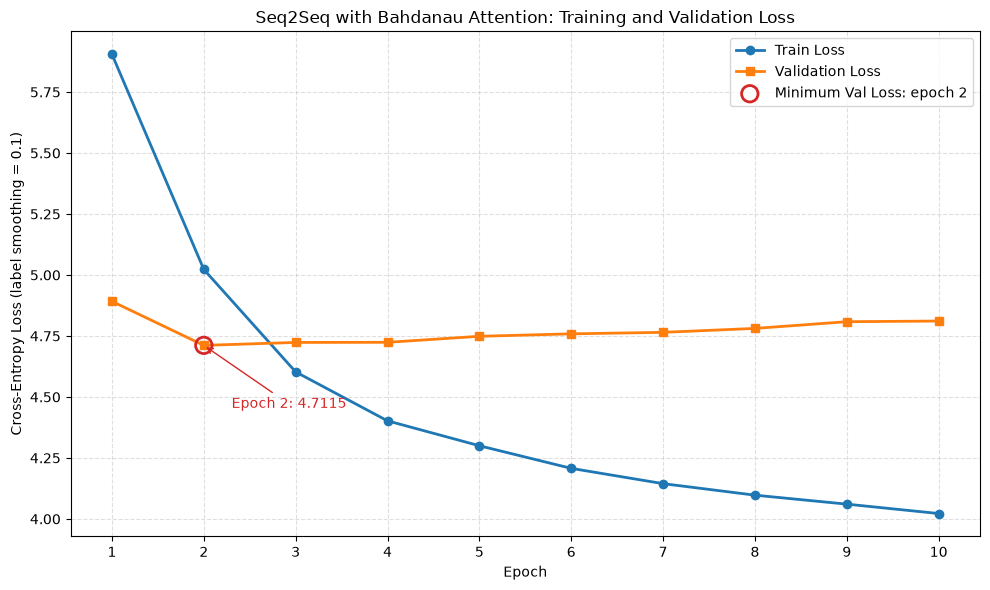

Графік збережено: G:\GOIT\GitHub\goit-dlcv-hw12\results\loss_history.png
Train Loss: 5.9047 → 4.0221
Мінімальний Validation Loss: 4.7115 (епоха 2)
Фінальний Validation Loss: 4.8112

Побудову та збереження графіка завершено.


In [46]:
# ===================================================================
# Крок 7.1. Візуалізація історії функції втрат
# ===================================================================

import json
from pathlib import Path
import matplotlib.pyplot as plt

results_dir = Path("results")
history_path = results_dir / "training_history.json"

# Завантаження збереженої історії.
with history_path.open("r", encoding="utf-8") as file:
    saved_results = json.load(file)

history = saved_results["history"]

epochs = history["epoch"]
train_losses = history["train_loss"]
val_losses = history["val_loss"]

assert len(epochs) == len(train_losses) == len(val_losses)
assert len(epochs) > 0

# Епоха з мінімальним validation loss.
best_val_loss_index = min(
    range(len(val_losses)),
    key=lambda i: val_losses[i],
)

best_val_loss_epoch = epochs[best_val_loss_index]
best_val_loss = val_losses[best_val_loss_index]

# Побудова графіка.
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    epochs,
    train_losses,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Train Loss",
)

ax.plot(
    epochs,
    val_losses,
    marker="s",
    linewidth=2,
    color="tab:orange",
    label="Validation Loss",
)

ax.scatter(
    [best_val_loss_epoch],
    [best_val_loss],
    s=140,
    facecolors="none",
    edgecolors="tab:red",
    linewidths=2,
    zorder=5,
    label=f"Minimum Val Loss: epoch {best_val_loss_epoch}",
)

ax.annotate(
    f"Epoch {best_val_loss_epoch}: {best_val_loss:.4f}",
    xy=(best_val_loss_epoch, best_val_loss),
    xytext=(20, -45),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "tab:red"},
    color="tab:red",
)

ax.set_title("Seq2Seq with Bahdanau Attention: Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss (label smoothing = 0.1)")
ax.set_xticks(epochs)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

fig.tight_layout()

# Збереження перед відображенням.
plot_path = results_dir / "loss_history.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

assert plot_path.is_file() and plot_path.stat().st_size > 0

print(f"Графік збережено: {plot_path.resolve()}")
print(
    f"Train Loss: {train_losses[0]:.4f} → "
    f"{train_losses[-1]:.4f}"
)
print(
    f"Мінімальний Validation Loss: {best_val_loss:.4f} "
    f"(епоха {best_val_loss_epoch})"
)
print(f"Фінальний Validation Loss: {val_losses[-1]:.4f}")
print("\nПобудову та збереження графіка завершено.")

#### Аналіз динаміки функції втрат

За 10 епох навчальна функція втрат зменшилася з 5.9047 до
4.0221. Валідаційна функція втрат досягла мінімуму 4.7115
на другій епосі, після чого поступово зростала й на десятій
епосі становила 4.8112.

Отже, після другої епохи покращення навчальної функції втрат
не супроводжувалося покращенням валідаційної функції втрат.

Водночас Validation BLEU зріс із 0.0751 на першій епосі до
0.0976 на десятій. Мінімум Validation Loss і максимум
Validation BLEU припали на різні епохи. За використаним
критерієм вибору чекпоінта — максимальним Validation BLEU —
найкращою була модель десятої епохи.

Підсумковий Test BLEU цієї моделі становив 0.0943.

In [49]:
# ===================================================================
# Крок 8.1. Тестові переклади зі збереженням ваг уваги
# ===================================================================

import json
import random
from pathlib import Path

import torch

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

# Завантаження найкращого чекпоінта.
checkpoint = torch.load(
    "best_model.pt",
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Відновлення index -> token з поточних словників.
SRC_ITOS = {idx: token for token, idx in src_stoi.items()}
TRG_ITOS = {idx: token for token, idx in trg_stoi.items()}

assert len(SRC_ITOS) == model.encoder.embedding.num_embeddings
assert len(TRG_ITOS) == model.decoder.embedding.num_embeddings

assert SRC_ITOS[PAD_IDX] == "<pad>"
assert SRC_ITOS[BOS_IDX] == "<bos>"
assert SRC_ITOS[EOS_IDX] == "<eos>"

assert TRG_ITOS[PAD_IDX] == "<pad>"
assert TRG_ITOS[BOS_IDX] == "<bos>"
assert TRG_ITOS[EOS_IDX] == "<eos>"


@torch.no_grad()
def translate_with_attention(src_ids, max_new_tokens=50):
    """
    Вхід: закодоване EN-речення з <bos>/<eos>, без паддингу.
    Вихід: згенеровані токени та увага для кожного кроку.
    """
    if max_new_tokens < 1:
        raise ValueError("max_new_tokens має бути додатним.")

    src_ids = [int(idx) for idx in src_ids]

    assert src_ids[0] == BOS_IDX
    assert src_ids[-1] == EOS_IDX
    assert PAD_IDX not in src_ids
    assert all(0 <= idx < len(SRC_ITOS) for idx in src_ids)

    model.eval()
    device = next(model.parameters()).device

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device,
    )

    # Для pack_padded_sequence довжина залишається на CPU.
    src_lengths = torch.tensor(
        [len(src_ids)],
        dtype=torch.long,
    )

    src_mask = src.ne(PAD_IDX)

    encoder_outputs, hidden = model.encoder(src, src_lengths)

    input_token = torch.tensor(
        [BOS_IDX],
        dtype=torch.long,
        device=device,
    )

    generated_ids = []
    attention_rows = []
    ended_with_eos = False

    for _ in range(max_new_tokens):
        logits, hidden, weights = model.decoder(
            input_token,
            hidden,
            encoder_outputs,
            src_mask,
        )

        next_token = logits.argmax(dim=1)
        next_id = int(next_token.item())

        generated_ids.append(next_id)
        attention_rows.append(weights[0].detach().cpu())

        if next_id == EOS_IDX:
            ended_with_eos = True
            break

        input_token = next_token

    attention_matrix = torch.stack(attention_rows, dim=0)

    assert attention_matrix.shape == (
        len(generated_ids),
        len(src_ids),
    )
    assert torch.isfinite(attention_matrix).all()
    assert torch.all(attention_matrix >= 0)
    assert torch.allclose(
        attention_matrix.sum(dim=1),
        torch.ones(len(generated_ids)),
        atol=1e-5,
    )

    generated_tokens = [
        TRG_ITOS[idx] for idx in generated_ids
    ]

    # Для читабельного виводу прибираємо лише завершальний <eos>.
    # Інші спеціальні токени не приховуємо: це можливі помилки моделі.
    translation_tokens = (
        generated_tokens[:-1]
        if ended_with_eos
        else generated_tokens
    )

    return {
        "source_model_tokens": [
            SRC_ITOS[idx] for idx in src_ids
        ],
        "generated_ids": generated_ids,
        "generated_tokens": generated_tokens,
        "translation_tokens": translation_tokens,
        "prediction_tokenized": " ".join(translation_tokens),
        "ended_with_eos": ended_with_eos,
        "attention": attention_matrix.tolist(),
    }


# Використовуємо тестову вибірку поточного експерименту.
test_split = numericalized_dataset["test"]

N_EXAMPLES = 10
EXAMPLES_SEED = 42
MAX_NEW_TOKENS = 50

assert len(test_split) >= N_EXAMPLES

rng = random.Random(EXAMPLES_SEED)
example_indices = rng.sample(
    range(len(test_split)),
    k=N_EXAMPLES,
)

translation_examples = []

for number, test_index in enumerate(example_indices, start=1):
    row = test_split[test_index]

    decoded = translate_with_attention(
        src_ids=row["src_ids"],
        max_new_tokens=MAX_NEW_TOKENS,
    )

    example = {
        "example_number": number,
        "test_index": test_index,
        "original_index": int(row["original_index"]),
        "source_text": row["translation"]["en"],
        "reference_text": row["translation"]["de"],
        "source_tokens": list(row["src_tokens"]),
        "reference_tokens": list(row["trg_tokens"]),
        **decoded,
    }

    translation_examples.append(example)

    print(f"\nПриклад {number} | test_index={test_index}")
    print("EN:       ", example["source_text"])
    print("DE еталон:", example["reference_text"])
    print("DE модель:", example["prediction_tokenized"])
    print(
        "Увага:",
        (
            len(example["generated_tokens"]),
            len(example["source_model_tokens"]),
        ),
    )

    if not example["ended_with_eos"]:
        print(
            "Увага: генерація досягла ліміту "
            f"{MAX_NEW_TOKENS} токенів без <eos>."
        )

    unexpected_special_tokens = [
        token
        for token in example["translation_tokens"]
        if token in {"<pad>", "<bos>", "<unk>"}
    ]

    if unexpected_special_tokens:
        print(
            "Спеціальні токени у прогнозі:",
            unexpected_special_tokens,
        )


# Збереження прикладів і матриць уваги.
examples_path = results_dir / "translation_examples.json"

payload = {
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "checkpoint_val_bleu": float(checkpoint["val_bleu"]),
    "direction": "en -> de",
    "decoding": "greedy",
    "seed": EXAMPLES_SEED,
    "max_new_tokens": MAX_NEW_TOKENS,
    "examples": translation_examples,
}

with examples_path.open("w", encoding="utf-8") as file:
    json.dump(
        payload,
        file,
        ensure_ascii=False,
        indent=2,
        allow_nan=False,
    )

# Перевірка збереженого файлу.
assert examples_path.is_file()
assert examples_path.stat().st_size > 0

with examples_path.open("r", encoding="utf-8") as file:
    restored_examples = json.load(file)

assert restored_examples == payload

print("\n" + "=" * 70)
print(f"Чекпоінт: епоха {payload['checkpoint_epoch']}")
print(f"Згенеровано прикладів: {len(translation_examples)}")
print(f"Результати збережено: {examples_path.resolve()}")
print("Перевірку перекладів та матриць уваги пройдено.")
# Використовуємо


Приклад 1 | test_index=1309
EN:        It should be constructed within the Member States and the Community institutions.
DE еталон: Es sollte innerhalb der Mitgliedstaaten und der Institutionen der Gemeinschaft konzipiert werden.
DE модель: Sie sollte innerhalb Gemeinschaftsorganen Mitgliedstaaten den Gemeinschaftsorganen und den Gemeinschaftsorganen funktionieren .
Увага: (13, 15)

Приклад 2 | test_index=228
EN:        When, Mr President, will the Commission go further on spatial planning and submit new proposals to develop the decision taken at the informal Council meetings, notably at Potsdam and Tampere?
DE еталон: Wann, Herr Präsident, wird die Kommission die Raumplanung weiter vorantreiben und neue Vorschläge zur Weiterentwicklung der auf den informellen Ratstagungen vor allem von Potsdam und Tampere getroffenen Entscheidungen vorlegen?
DE модель: Herr Präsident , die Kommission wird die Kommission weiter auf neue und Vorschläge unterbreiten , um Vorschläge des Rates , den Rat ,


Приклад 4
EN:        The Stability and Growth Pact must be reformed and the rules tightened up.
DE еталон: Der Stabilitäts- und Wachstumspakt muss reformiert und die Regeln müssen verschärft werden.
DE модель: Der Stabilitäts- und Wachstumspakt muss reformiert und und die Vorschriften gelten .


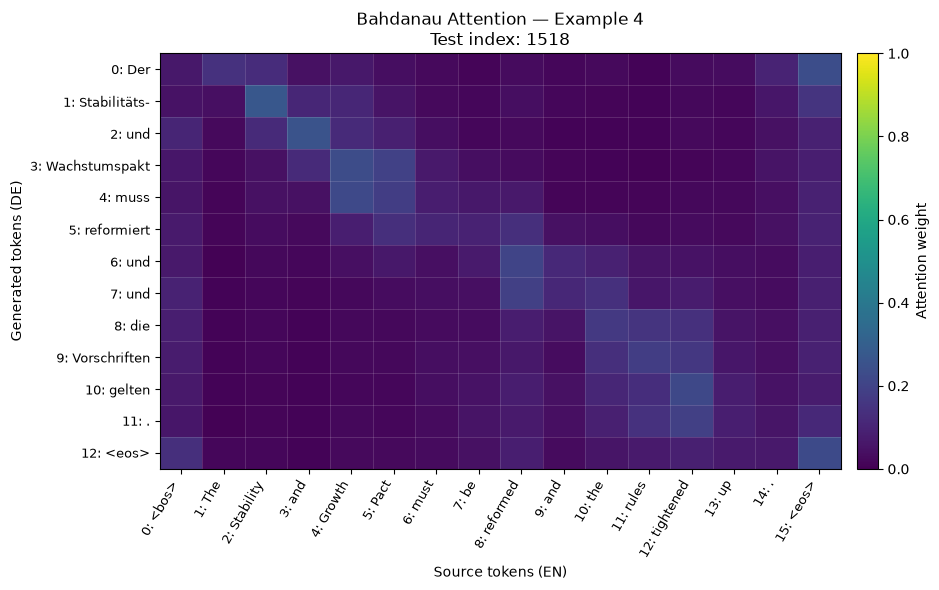

Графік збережено: G:\GOIT\GitHub\goit-dlcv-hw12\results\attention\attention_example_04.png

Приклад 9
EN:        But that is a matter for the Greek government.
DE еталон: Dies ist jedoch Sache der griechischen Regierung.
DE модель: Aber die Regierung ist aber die Regierung .


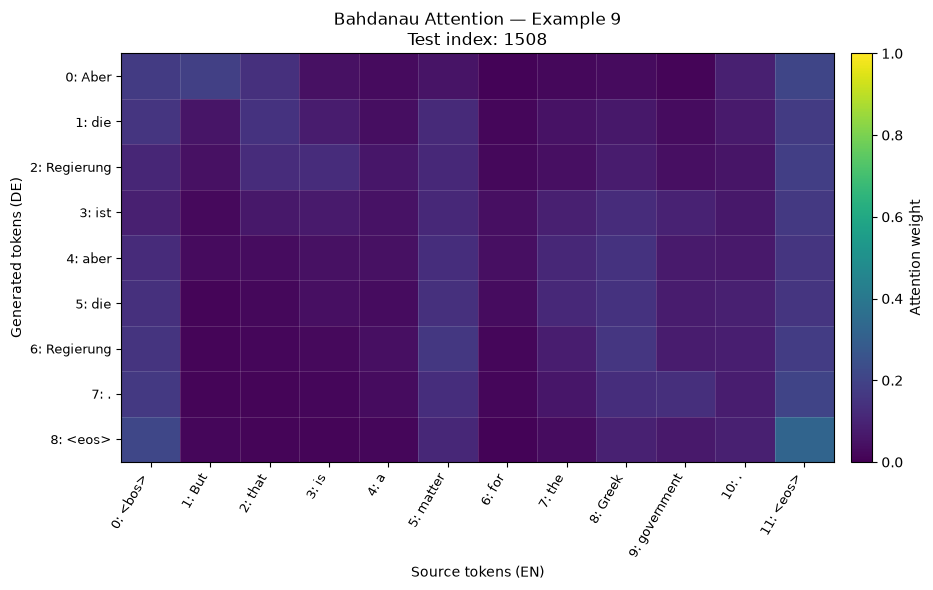

Графік збережено: G:\GOIT\GitHub\goit-dlcv-hw12\results\attention\attention_example_09.png

Приклад 10
EN:        Nevertheless, I shall, of course, look into the matter.
DE еталон: Aber ich werde mich natürlich um die Angelegenheit kümmern.
DE модель: Natürlich werde ich natürlich natürlich prüfen .


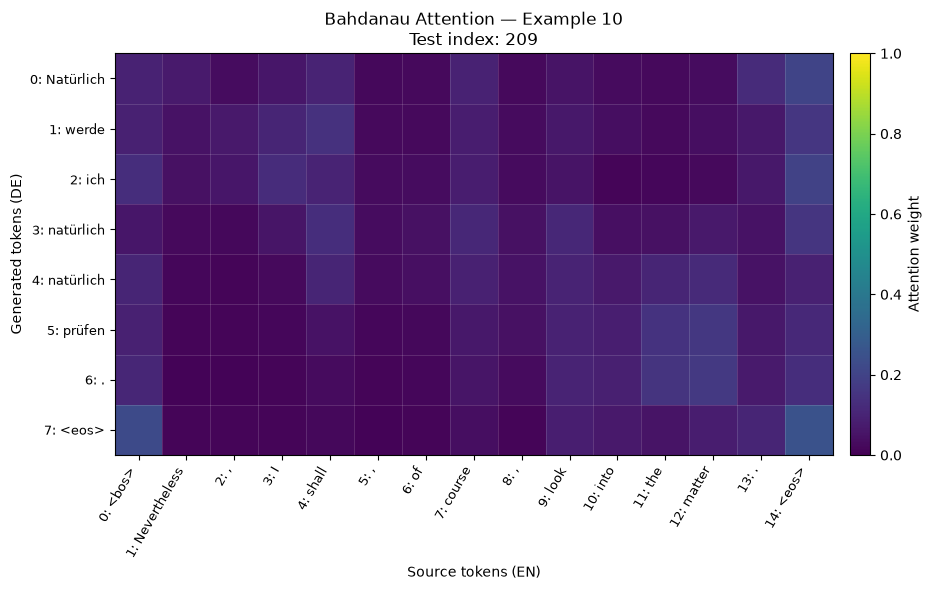

Графік збережено: G:\GOIT\GitHub\goit-dlcv-hw12\results\attention\attention_example_10.png


In [51]:
# ===================================================================
# Крок 8.2. Візуалізація уваги для тестових перекладів
# ===================================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

results_dir = Path("results")
examples_path = results_dir / "translation_examples.json"

attention_dir = results_dir / "attention"
attention_dir.mkdir(parents=True, exist_ok=True)

# Завантаження збережених перекладів та ваг уваги.
with examples_path.open("r", encoding="utf-8") as file:
    saved_examples = json.load(file)

examples_by_number = {
    example["example_number"]: example
    for example in saved_examples["examples"]
}

SELECTED_EXAMPLES = [4, 9, 10]

saved_plot_paths = []

for example_number in SELECTED_EXAMPLES:
    example = examples_by_number[example_number]

    source_tokens = example["source_model_tokens"]
    generated_tokens = example["generated_tokens"]

    attention = np.asarray(
        example["attention"],
        dtype=np.float32,
    )

    # Перевірка відповідності матриці підписам осей.
    assert attention.shape == (
        len(generated_tokens),
        len(source_tokens),
    )
    assert np.isfinite(attention).all()
    assert np.all(attention >= 0)
    assert np.allclose(
        attention.sum(axis=1),
        1.0,
        atol=1e-5,
    )

    figure_width = max(10, 0.55 * len(source_tokens))
    figure_height = max(6, 0.40 * len(generated_tokens))

    fig, ax = plt.subplots(
        figsize=(figure_width, figure_height),
    )

    image = ax.imshow(
        attention,
        cmap="viridis",
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )

    # Додаємо позиції, щоб розрізняти повторювані токени.
    ax.set_xticks(np.arange(len(source_tokens)))
    ax.set_xticklabels(
        [
            f"{position}: {token}"
            for position, token in enumerate(source_tokens)
        ],
        rotation=60,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(np.arange(len(generated_tokens)))
    ax.set_yticklabels(
        [
            f"{position}: {token}"
            for position, token in enumerate(generated_tokens)
        ],
        fontsize=9,
    )

    ax.set_xlabel("Source tokens (EN)")
    ax.set_ylabel("Generated tokens (DE)")
    ax.set_title(
        f"Bahdanau Attention — Example {example_number}\n"
        f"Test index: {example['test_index']}"
    )

    # Межі клітинок.
    ax.set_xticks(
        np.arange(-0.5, len(source_tokens), 1),
        minor=True,
    )
    ax.set_yticks(
        np.arange(-0.5, len(generated_tokens), 1),
        minor=True,
    )
    ax.grid(
        which="minor",
        color="white",
        linewidth=0.4,
        alpha=0.25,
    )
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label("Attention weight")

    fig.tight_layout()

    plot_path = (
        attention_dir / f"attention_example_{example_number:02d}.png"
    )

    fig.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"\nПриклад {example_number}")
    print("EN:       ", example["source_text"])
    print("DE еталон:", example["reference_text"])
    print("DE модель:", example["prediction_tokenized"])

    plt.show()
    plt.close(fig)

    assert plot_path.is_file()
    assert plot_path.stat().st_size > 0

    saved_plot_paths.append(plot_path)

    print(f"Графік збережено: {plot_path.resolve()}")



#### Інтерпретація механізму уваги

Для аналізу було побудовано матриці уваги для трьох тестових прикладів. Стовпці відповідають вхідним англійським токенам, а рядки — згенерованим німецьким токенам. Колір відображає вагу уваги до відповідної вхідної позиції на кожному кроці декодування. До візуалізації включено спеціальні токени <bos> та <eos>.

#### Загальний висновок

Увага демонструє часткові відповідності між вхідними та вихідними позиціями. Найбільш виразна послідовна структура спостерігається у прикладі 4, де початок перекладу також відтворено краще.
В інших прикладах увага більш розподілена, а переклади містять пропуски й повторення. Проте матриці уваги не дають достатніх підстав стверджувати, що саме певний розподіл ваг спричинив конкретну помилку.

Усі графіки мають спільну шкалу від 0 до 1. Відсутність яскравих жовтих клітинок означає, що на показаних кроках вага не зосереджена майже повністю на одній позиції. Темні клітинки не обов'язково мають нульову вагу.

Висновки стосуються трьох розглянутих прикладів і не є повною характеристикою поведінки уваги на всьому тестовому наборі.

### Загальний висновок:

Реалізовано повний цикл навчання й оцінювання, перевірка розділення даних, побудова словників лише за train, коректне використання паддингу та масок, збереження чекпоінта, метрик і прикладів із вагами уваги.

Основні обмеження експерименту:
- використано лише частину початкового корпусу та речення довжиною до 40 токенів.
- словникове кодування не розбиває рідкісні слова на підслова. Частка невідомих німецьких токенів у test становила 3.32%.
- серед розглянутих прикладів виявлено змістово неузгоджену пару EN/DE, що вказує на необхідність додаткової перевірки вирівнювання корпусу.

